# Clustering Analysis (Customer Segmentation)

This notebook explores the data with a focus on **Customer Segmentation** (Clustering).
**Goal:** Identify distinct groups of leads/customers.

## Questions:
1. Are there natural clusters in the data?
2. Can we visualize these clusters using PCA or t-SNE?

In [1]:
import sys
import os
from pathlib import Path

current_dir = Path(os.getcwd())
project_root = None
for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from src.data.funnel_loader import FunnelDataLoader
from src.config import load_config

%matplotlib inline

## 1. Load Data

In [2]:
try:
    config = load_config("config.yaml")
    config_dict = config.model_dump()
except:
    config_dict = {}

loader = FunnelDataLoader(config_dict)
df = loader.load_and_process()
print(f"Data loaded: {df.shape}")
df.head()

Data loaded: (31280, 23)


,Status,LeadSource,CreatedDate,AnnualRevenue,Sector,ProductInterest,State,IsConverted,StageName,Amount,...,Product,Selic,IPCA,Dollar,Close,High,Low,Open,Volume,PIB_Per_Capita
0,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,145517.0,146879.0,145193.0,146237.0,8340700,949300770.0
1,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,143950.0,145621.0,143635.0,145517.0,7245600,949300770.0
2,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,144201.0,144518.0,143676.0,143950.0,6177600,949300770.0
3,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,143608.0,144532.0,143376.0,144202.0,5981500,949300770.0
4,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,141356.0,143606.0,141035.0,143606.0,9272700,949300770.0


## 2. Preprocessing for Clustering

In [3]:
numeric_features = ['AnnualRevenue', 'Selic', 'IPCA', 'Dollar', 'Close', 'PIB_Per_Capita']
categorical_features = ['Sector', 'LeadSource']

df_clean = df.dropna(subset=numeric_features + categorical_features).copy()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

X = preprocessor.fit_transform(df_clean)
print(f"Processed shape: {X.shape}")

Processed shape: (21553, 16)


## 3. Dimensionality Reduction (PCA)

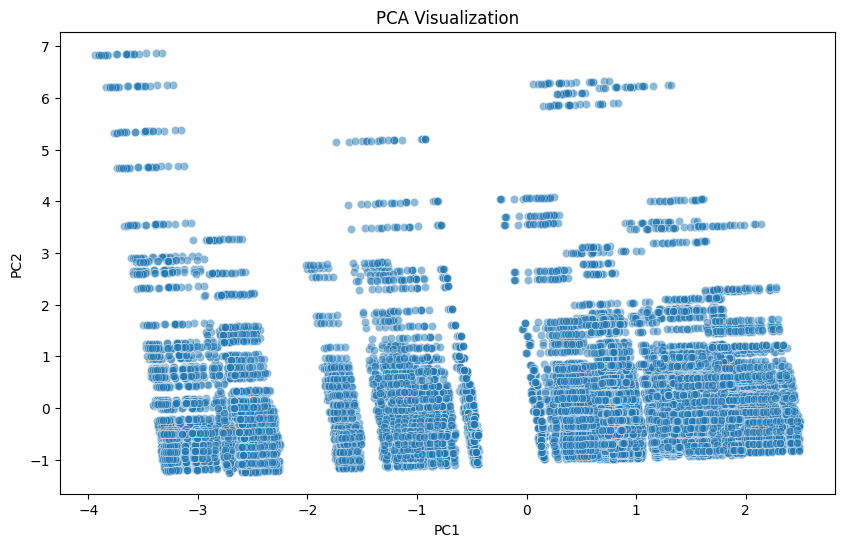

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.5)
plt.title('PCA Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## 4. Clustering (K-Means)

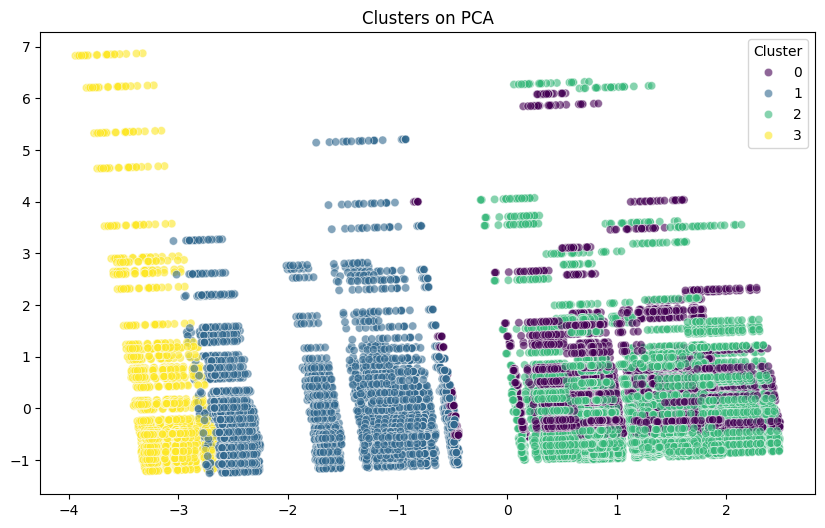

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)
df_clean['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['Cluster'], palette='viridis', alpha=0.6)
plt.title('Clusters on PCA')
plt.show()

## 5. Cluster Profiling

In [6]:
profile_cols = numeric_features + ['Amount']
profile_cols = [c for c in profile_cols if c in df_clean.columns]
print(df_clean.groupby('Cluster')[profile_cols].mean())

         AnnualRevenue     Selic      IPCA    Dollar          Close  \
Cluster                                                               
0         7.774236e+06  0.054763  0.206435  5.501550  138947.224704   
1         8.122978e+06  0.050817  0.734782  5.765404  128442.071014   
2         7.286518e+06  0.054868  0.191841  5.484516  139408.656580   
3         1.186978e+07  0.045833  0.160000  6.021173  121901.181818   

         PIB_Per_Capita        Amount  
Cluster                                
0          9.039284e+08  81608.707393  
1          5.806060e+08  89988.642511  
2          4.118606e+08  65643.372536  
3          5.422831e+08  82007.214286  


## 6. Final Analysis & Conclusions

Based on the K-Means clustering (k=4) and PCA visualization, here are the answers to the initial questions:

### 1. Are there natural clusters in the data?
**Yes, distinct clusters were identified.**
The analysis reveals 4 main groups of customers/leads, primarily differentiated by their **Annual Revenue** and **Deal Size (Amount)**:

- **Cluster 3 (High Value):** Companies with the highest average Annual Revenue (~R$ 11.8M) and solid Deal Sizes (~R$ 82k).
- **Cluster 2 (Lower Value):** Companies with lower Annual Revenue (~R$ 7.2M) and the smallest average Deal Size (~R$ 65k).
- **Clusters 0 & 1:** Represent the middle ground, with average revenues around R$ 7.7M - 8.1M.

This segmentation allows for targeted marketing strategies (e.g., premium services for Cluster 3).

### 2. Can we visualize these clusters using PCA?
**Yes.**
The PCA visualization clearly shows the separation of these groups in the reduced 2D space. The clusters form distinct regions, confirming that the selected features (Revenue, Sector, Market Indicators) are effective in distinguishing between different types of customers.